In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
df = pd.read_csv('../data/engineered.csv', index_col=0)

In [166]:
df.duplicated(subset=['track_title', 'artist_name']).sum()

np.int64(130)

In [167]:
df.duplicated(subset=['genius_song_id']).sum()

np.int64(402)

In [168]:
df = df.drop_duplicates(subset=['genius_song_id'], keep='first')

In [169]:
df.isna().sum().reset_index().groupby(0).agg(list)

,index
0,
0,"[date, artist_name, days_on_chart, top_10_days..."
1,"[genius_song_id, genius_artist_id, feat_artist..."
6,[track_title]
33,[language]
42,"[lyrics, lyrics_words_count, chorus_count, lyr..."
43,[lyrics_mean_word_length]
264,[release_date]
366,[youtube_url]
426,[artist_description_mean_word_length]


In [170]:
df = df.dropna(subset=['track_title', 'genius_song_id'])

In [171]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_day'] = df['release_date'].dt.day

In [172]:
df['len_title'] = df['track_title'].str.split().str.len()
df['len_album'] = df['album'].str.split().str.len()

In [173]:
df['primary_color'] = df['primary_color'].apply(lambda x: int(x[1:], 16))
df['secondary_color'] = df['secondary_color'].apply(lambda x: int(x[1:], 16))
df['text_color'] = df['text_color'].apply(lambda x: int(x[1:], 16))

In [174]:
df['has_sample'] = df['has_sample'].astype(int)
df['is_cover'] = df['is_cover'].astype(int)
df['is_remix'] = df['is_remix'].astype(int)
df['is_translation'] = df['is_translation'].astype(int)

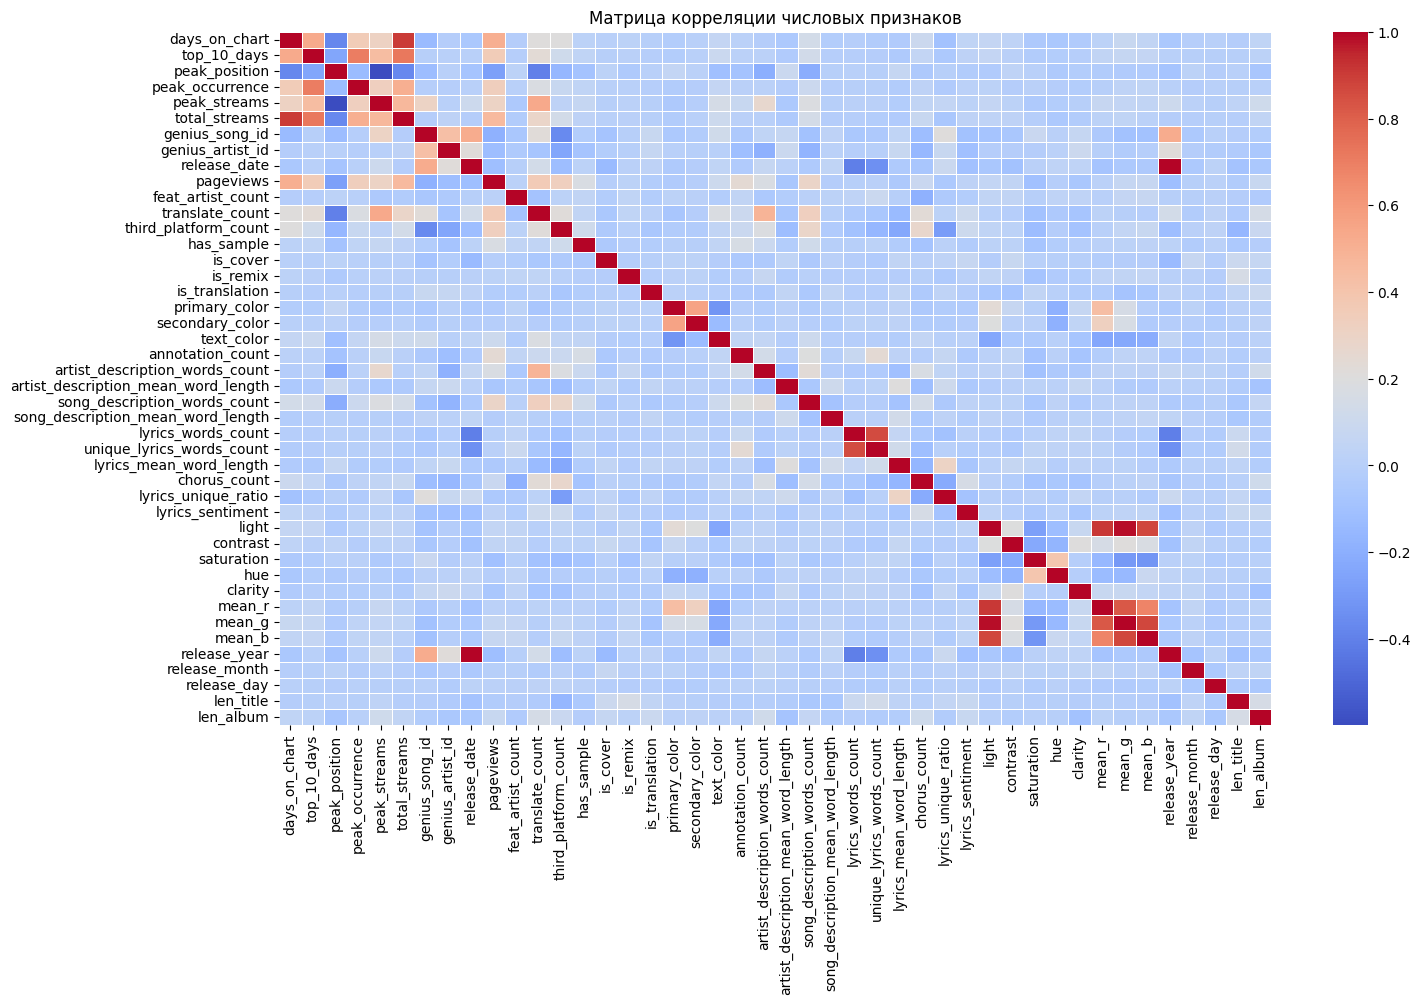

In [175]:
correlation_matrix = df.select_dtypes(include=['int64', 'float64', np.datetime64]).corr()

plt.figure(figsize=(16, 9))
sns.heatmap(correlation_matrix, cmap='coolwarm', linewidths=0.5)
plt.title('Матрица корреляции числовых признаков')
plt.show()

In [176]:
# sns.pairplot(df.select_dtypes(include=['int64', 'float64', np.datetime64]), diag_kind='kde')

In [177]:
df = df.drop(columns=['image_url', 'youtube_url', 'genius_song_url', 'url', 'date'])

In [ ]:
df = df[df['is_translation'] == 0]

In [185]:
df.groupby('language')['artist_name'].nunique().sort_values(ascending=False).head(10)

language
en    1486
es     285
pt     190
de      65
ko      56
it      53
fr      37
tr      26
id      22
pl      21
Name: artist_name, dtype: int64

In [196]:
df['artist_name'].drop_duplicates().str.lower().str.split().explode().value_counts().head(20)

artist_name
the      79
&        49
mc       40
dj       25
lil      17
la       14
james    11
john     10
of       10
de       10
young     8
jack      8
king      8
e         8
sam       7
chris     7
black     7
da        7
david     6
el        6
Name: count, dtype: int64

In [192]:
df['track_title'].str.lower().str.split().explode().value_counts().head(20)

track_title
the          708
-            495
you          463
me           445
i            362
love         303
a            269
it           237
my           234
to           233
in           217
of           211
on           186
remix        168
no           163
up           143
for          137
christmas    120
&            119
la           114
Name: count, dtype: int64

In [ ]:
df['album'].str.lower().str.split().explode().value_counts().head(20)

album
the           1549
edition)      1187
(deluxe)       790
of             436
a              389
-              332
version)       319
(japan         308
2              282
i              279
you            266
(japanese      248
music          238
to             230
(deluxe        222
&              204
love           187
for            166
exclusive)     166
in             165
Name: count, dtype: int64

In [197]:
df['song_description'].str.lower().str.split().explode().value_counts().head(20)

song_description
the     56063
and     22401
a       21831
of      19851
to      17187
on      15837
in      14731
is      11480
song    10649
was      8947
with     8882
that     7553
his      7119
as       6682
for      6489
it       6354
.        6137
,        6032
this     5686
by       5227
Name: count, dtype: int64

In [198]:
df['artist_description'].str.lower().str.split().explode().value_counts().head(20)

artist_description
the         220984
and         115986
of           91147
in           88476
a            85540
,            78097
on           77798
to           72926
his          57727
with         51265
was          49224
.            46262
released     42033
album        38364
as           37496
for          34278
her          31684
he           26204
de           22191
first        21957
Name: count, dtype: int64

In [199]:
df['lyrics'].str.lower().str.split().explode().value_counts().head(20)

lyrics
the     200593
i       153530
you     117396
a       106965
and      96114
to       94157
of       71005
in       69174
me       69033
my       61690
it       57848
that     50763
on       45179
i'm      44578
-        44161
with     32898
no       32898
for      32785
like     31927
your     30973
Name: count, dtype: int64

<Axes: xlabel='lyrics_sentiment', ylabel='Count'>

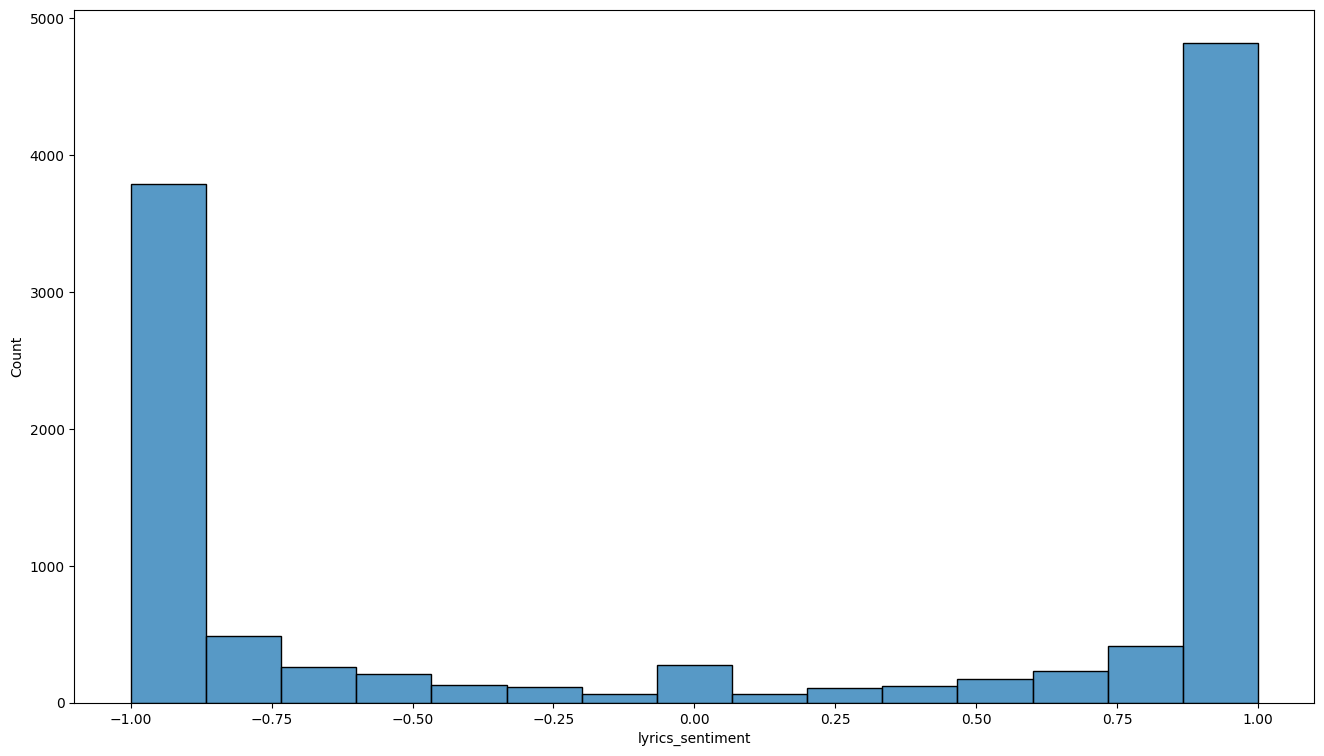

In [204]:
plt.figure(figsize=(16, 9))
sns.histplot(data=df, x='lyrics_sentiment')

<Axes: xlabel='lyrics_sentiment', ylabel='peak_position'>

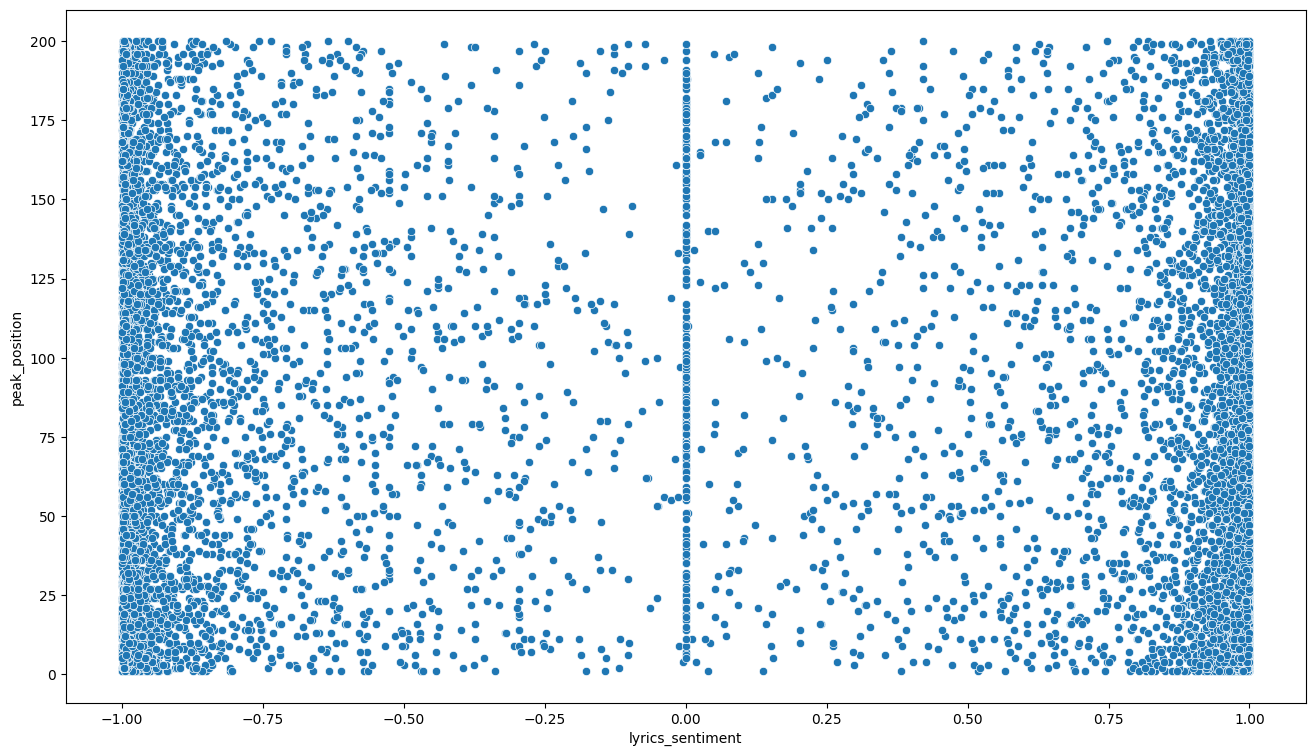

In [202]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df, x='lyrics_sentiment', y='peak_position')

(0.0, 1000.0)

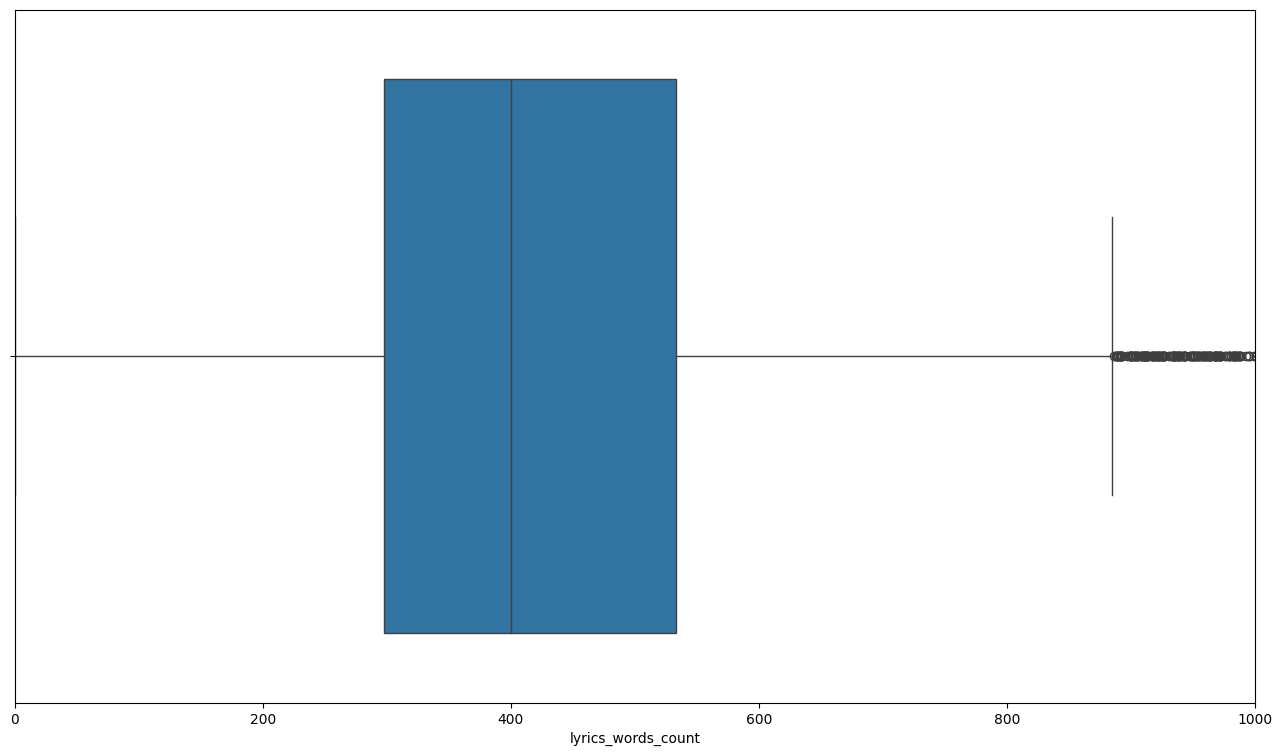

In [213]:
plt.figure(figsize=(16, 9))
sns.boxplot(data=df, x='lyrics_words_count')
plt.xlim(0, 1000)

<Axes: xlabel='lyrics_words_count', ylabel='peak_position'>

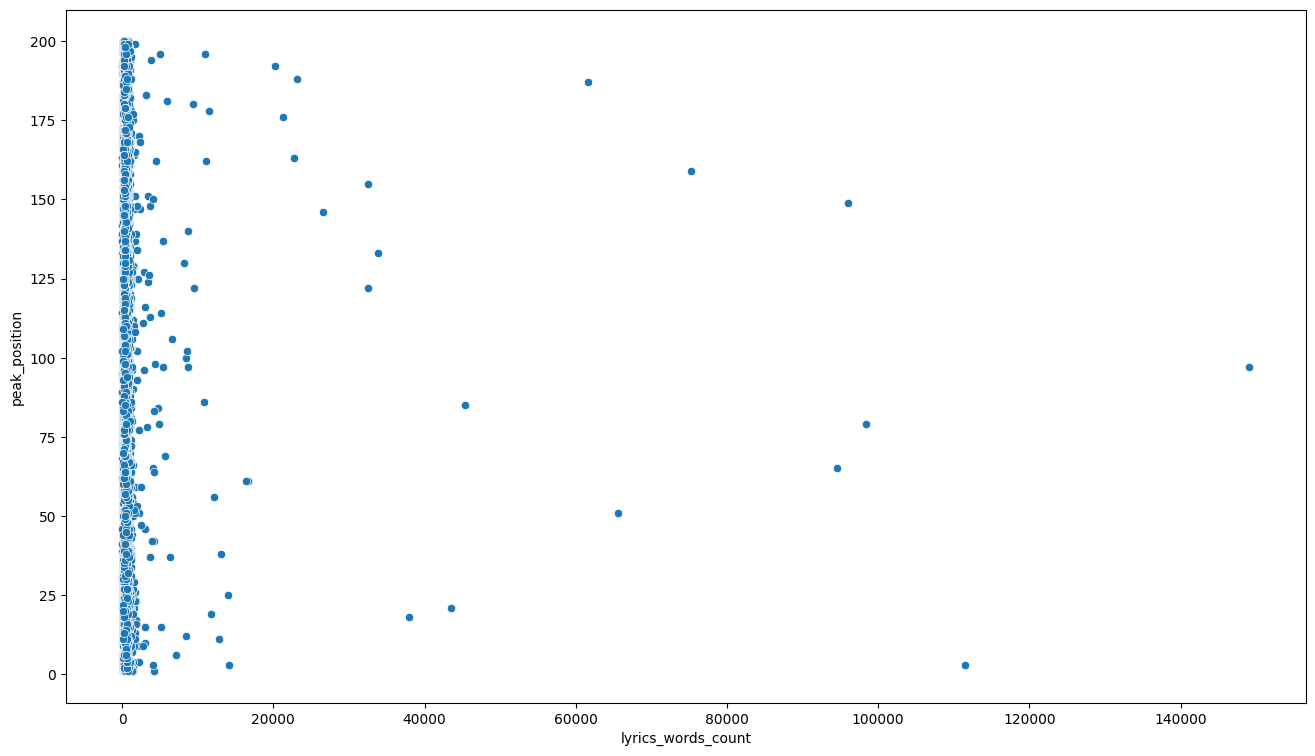

In [214]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df, x='lyrics_words_count', y='peak_position')

<Axes: xlabel='has_sample', ylabel='Count'>

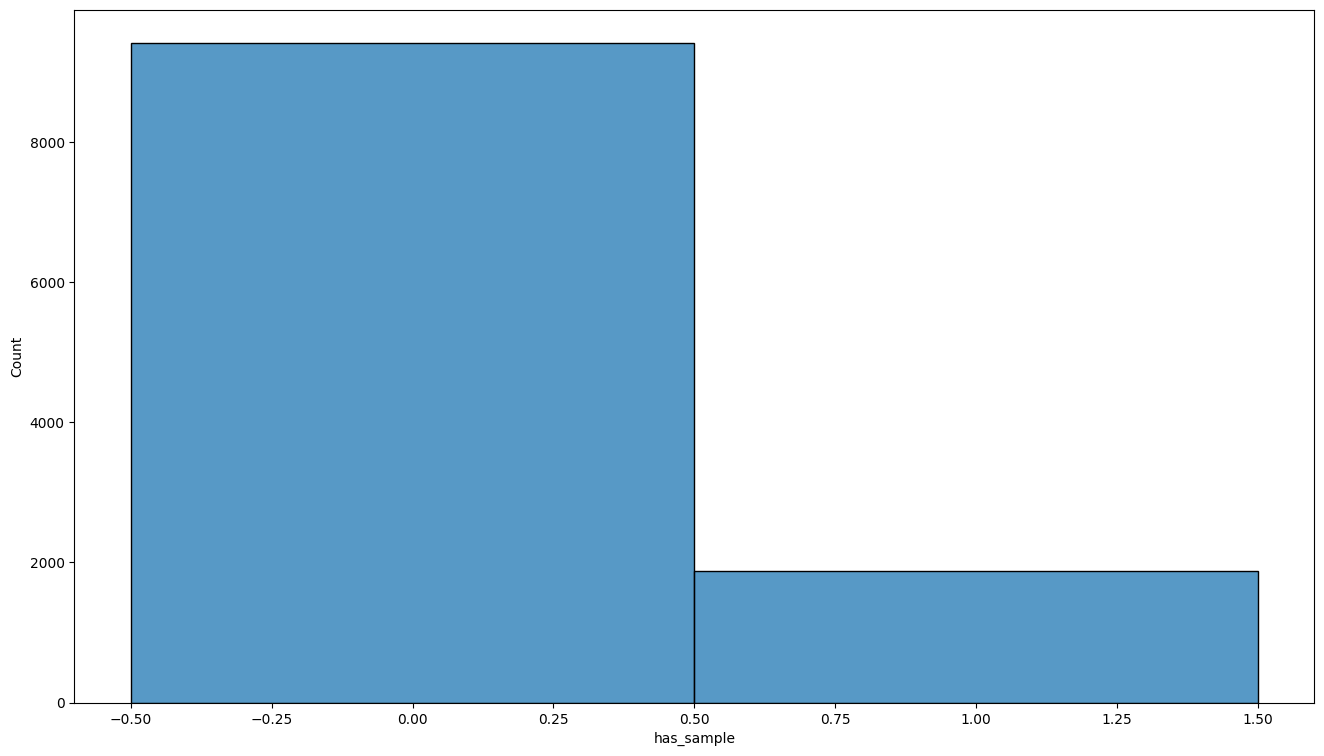

In [218]:
plt.figure(figsize=(16, 9))
sns.histplot(data=df, x='has_sample', discrete=True)

<Axes: xlabel='is_cover', ylabel='Count'>

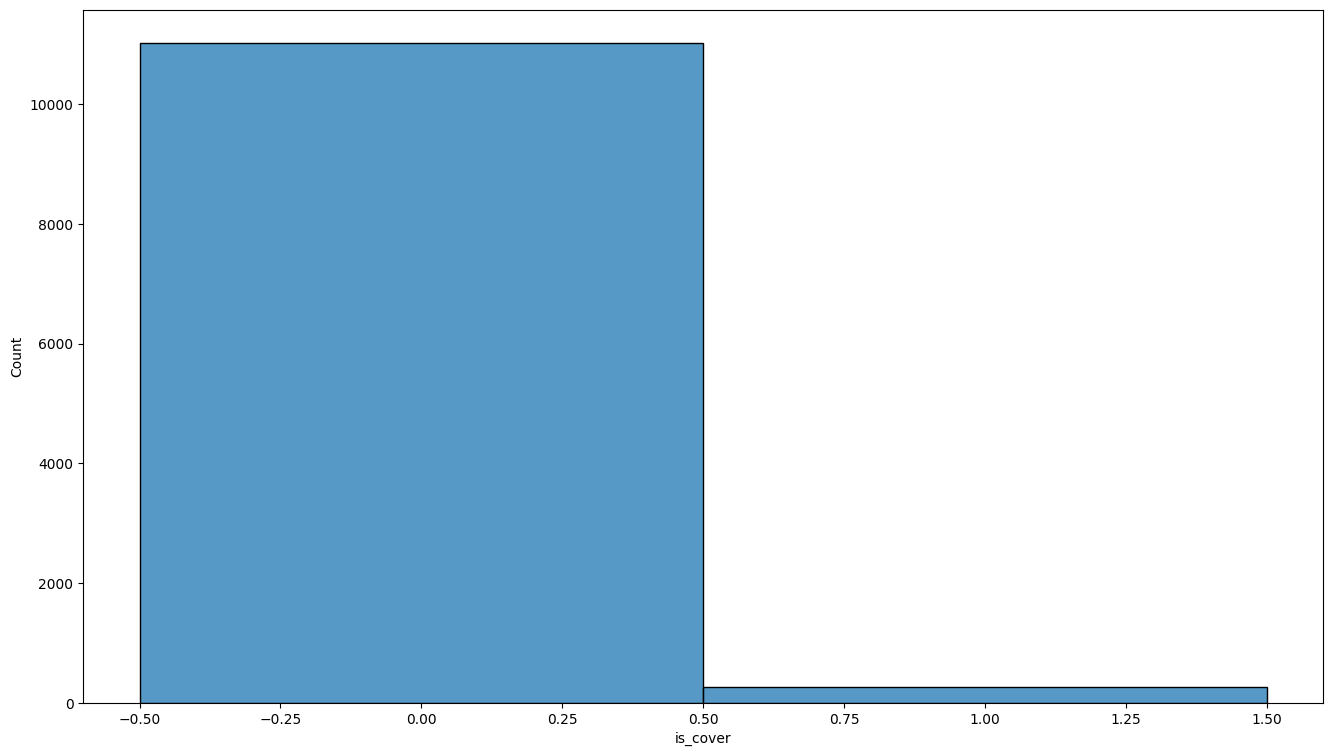

In [219]:
plt.figure(figsize=(16, 9))
sns.histplot(data=df, x='is_cover', discrete=True)

<Axes: xlabel='is_remix', ylabel='Count'>

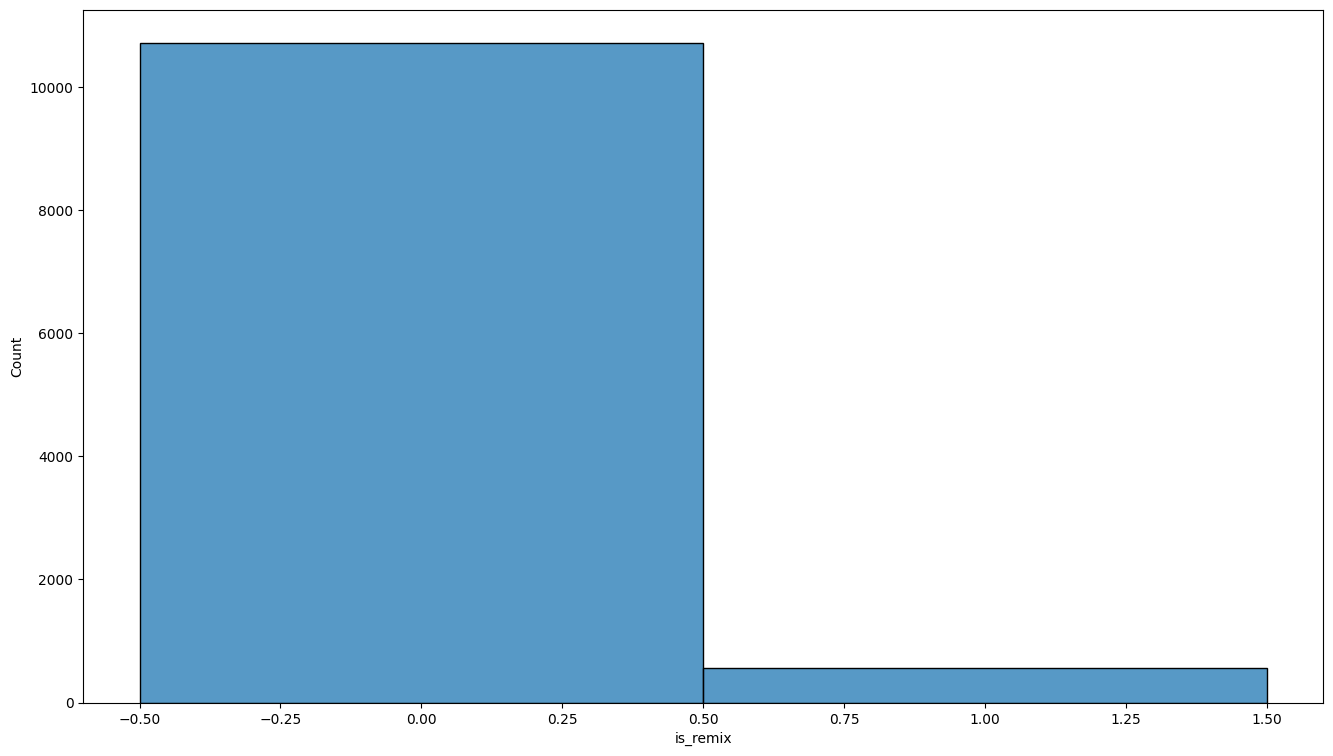

In [220]:
plt.figure(figsize=(16, 9))
sns.histplot(data=df, x='is_remix', discrete=True)

In [221]:
df.groupby('is_cover')['peak_position'].mean()

is_cover
0    85.331852
1    95.134387
Name: peak_position, dtype: float64

In [222]:
df.groupby('is_remix')['peak_position'].mean()

is_remix
0    86.065647
1    75.673835
Name: peak_position, dtype: float64

In [223]:
df.groupby('has_sample')['peak_position'].mean()

has_sample
0    87.893115
1    73.766845
Name: peak_position, dtype: float64

<Axes: xlabel='release_month'>

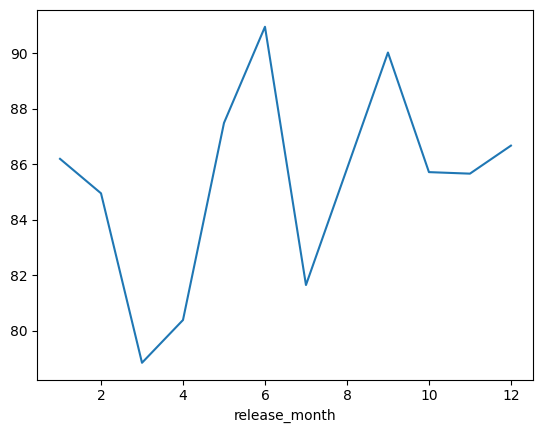

In [230]:
df.groupby('release_month')['peak_position'].mean().plot()

<Axes: xlabel='release_day'>

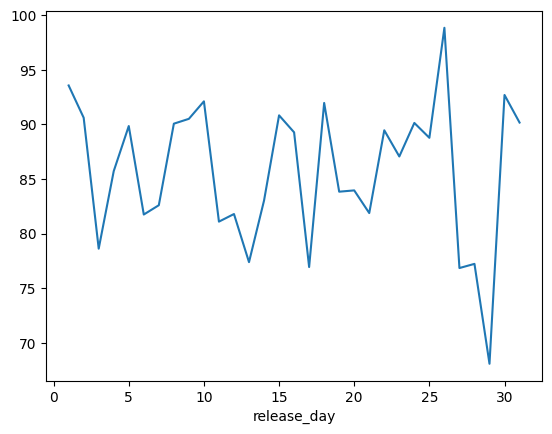

In [231]:
df.groupby('release_day')['peak_position'].mean().plot()

<Axes: xlabel='release_day_of_week'>

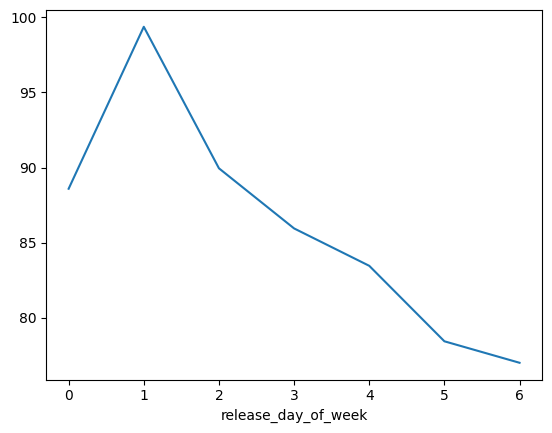

In [235]:
df['release_day_of_week'] = df['release_date'].dt.day_of_week

df.groupby('release_day_of_week')['peak_position'].mean().plot()

In [229]:
df.sort_values('release_year')

,artist_name,track_title,days_on_chart,top_10_days,peak_position,peak_occurrence,peak_streams,total_streams,genius_song_id,genius_artist_id,...,hue,clarity,mean_r,mean_g,mean_b,release_year,release_month,release_day,len_title,len_album
rank,,,,,,,,,,,,,,,,,,,,,
7444,Master CC,METAMORPHOSIS,3,0,159,1,1226948,3495825,179977.0,15985.0,...,NaN,NaN,NaN,NaN,NaN,1580.0,3.0,1.0,1,5.0
8552,New Politics,Everywhere I Go (Kings and Queens),12,0,126,1,166387,1752905,162032.0,53691.0,...,NaN,NaN,NaN,NaN,NaN,1837.0,5.0,9.0,6,3.0
8822,GoldSkull,TO THE,2,0,130,1,783737,1549314,158782.0,38011.0,...,NaN,NaN,NaN,NaN,NaN,1853.0,1.0,27.0,2,1.0
6587,22 Savage,The Race,12,0,170,1,529066,5889120,504140.0,214200.0,...,NaN,NaN,NaN,NaN,NaN,1871.0,5.0,1.0,2,7.0
8231,Matthew Koma,So F**kin' Romantic,10,0,149,1,220078,2110017,187785.0,60165.0,...,NaN,NaN,NaN,NaN,NaN,1885.0,9.0,12.0,3,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11699,Elina Born & Stig Rästa,Goodbye To Yesterday,1,0,164,1,187762,187762,7882852.0,407380.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,6.0
11702,Greg Lake,I Believe in Father Christmas,1,0,200,1,186899,186899,1541283.0,86379.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,11.0
11712,Ten Walls,Walking with Elephants,1,0,198,1,175823,175823,2177078.0,521451.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,8.0
